# GC Example 06: Half-Mass Radius Distribution

**EPS Research — Milky Way GC Corpus v1.3.1**

Half-mass radius r_hm from Baumgardt N-body models.
Correlates with age and dynamical state.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907765  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.1.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174


Clusters with r_hm: 154
r_hm range: 1.5 -- 37.7 pc
Median r_hm: 4.3 pc
r(log mass, log r_hm) = -0.366


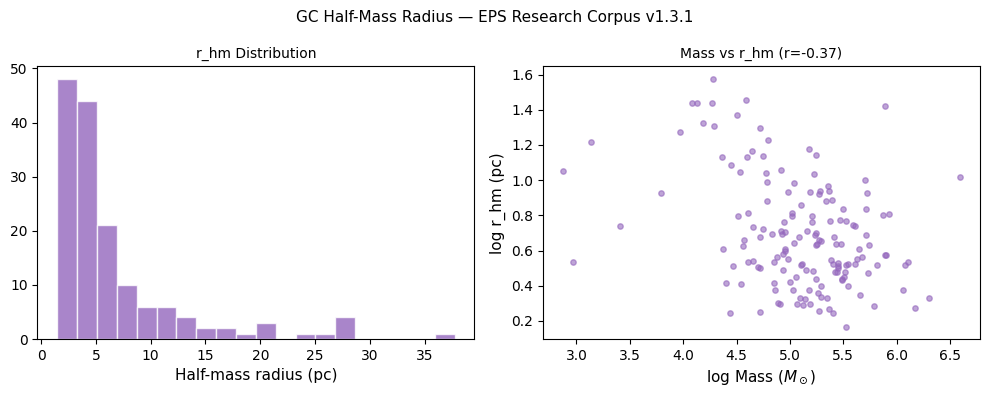

In [2]:
data=[(c['cluster_id'],c['baumgardt2023']['rhm_pc'],c['baumgardt2023']['mass_msun'])
      for c in clusters if c.get('baumgardt2023') and c['baumgardt2023'].get('rhm_pc')]
rhm=[d[1] for d in data]; mass=[d[2] for d in data]
print(f"Clusters with r_hm: {len(data)}")
print(f"r_hm range: {min(rhm):.1f} -- {max(rhm):.1f} pc")
print(f"Median r_hm: {np.median(rhm):.1f} pc")
corr=np.corrcoef(np.log10(mass),np.log10(rhm))[0,1]
print(f"r(log mass, log r_hm) = {corr:.3f}")
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].hist(rhm,bins=20,color='#9467bd',alpha=0.8,edgecolor='white')
axes[0].set_xlabel('Half-mass radius (pc)',fontsize=11); axes[0].set_title('r_hm Distribution',fontsize=10)
axes[1].scatter(np.log10(mass),np.log10(rhm),s=15,alpha=0.6,color='#9467bd')
axes[1].set_xlabel(r'log Mass ($M_\odot$)',fontsize=11); axes[1].set_ylabel('log r_hm (pc)',fontsize=11)
axes[1].set_title(f'Mass vs r_hm (r={corr:.2f})',fontsize=10)
plt.suptitle('GC Half-Mass Radius — EPS Research Corpus v1.3.1',fontsize=11)
plt.tight_layout(); plt.savefig('gc06_rhm.png',dpi=150,bbox_inches='tight'); plt.show()